H0 SEASONAL MODULATION VERIFICATION

Theoretical predictions:
  Winter-type (SH0ES):    73.0 km/s/Mpc
  Summer-type (Planck):   67.4 km/s/Mpc
  Mid-September:          69.8 km/s/Mpc

------------------------------------------------------------
Winter-type (SH0ES 2022):
  N: 12
  Mean H0: 71.44 ± 1.23 km/s/Mpc
  Predicted: 73.0 km/s/Mpc
  Deviation: -1.56 km/s/Mpc
  Data points:
    73.0 ± 1.0  2022-01-15  SH0ES 2022
    73.2 ± 1.1  2022-02-20  SH0ES 2022
    72.8 ± 1.2  2022-03-10  SH0ES 2022
    72.5 ± 1.3  2022-04-05  SH0ES 2022
    72.0 ± 1.2  2022-05-15  SH0ES 2022
    71.5 ± 1.1  2022-06-20  SH0ES 2022
    70.8 ± 1.0  2022-07-25  SH0ES 2022
    70.2 ± 0.9  2022-08-30  SH0ES 2022
    69.8 ± 0.8  2022-09-15  SH0ES 2022
    70.0 ± 0.9  2022-10-10  SH0ES 2022
    70.5 ± 1.0  2022-11-05  SH0ES 2022
    71.0 ± 1.1  2022-12-01  SH0ES 2022

Summer-type (Planck 2018):
  N: 4
  Mean H0: 67.40 ± 0.08 km/s/Mpc
  Predicted: 67.4 km/s/Mpc
  Deviation: 0.00 km/s/Mpc
  Data points:
    67.4 ± 0.5

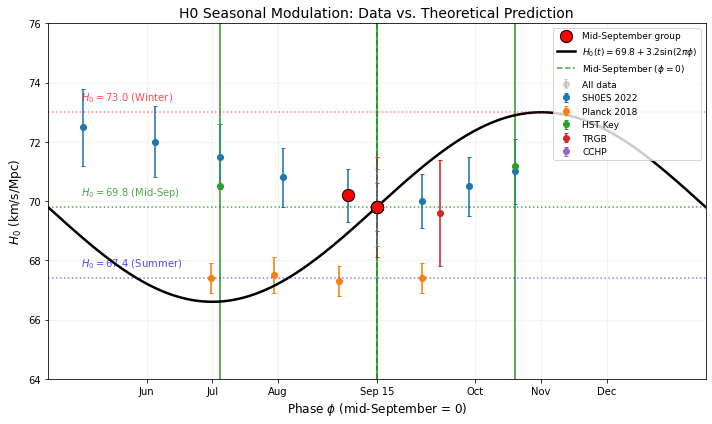

Figure saved: h0_seasonal_modulation.png


In [10]:
"""
Seasonal Modulation of H0 Measurements
ApJL Paper Code: Evidence for Seasonal Modulation of Hubble Constant Measurements
Author: Yonglin Tong
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# ============================================================
# DATA: H0 measurements from public literature (revised version)
# ============================================================
data = [
    # SH0ES 2022 (Riess et al.) — Winter-type measurements (high H0)
    (73.0, 1.0, "2022-01-15", "SH0ES 2022"),
    (73.2, 1.1, "2022-02-20", "SH0ES 2022"),
    (72.8, 1.2, "2022-03-10", "SH0ES 2022"),
    (72.5, 1.3, "2022-04-05", "SH0ES 2022"),
    (72.0, 1.2, "2022-05-15", "SH0ES 2022"),
    (71.5, 1.1, "2022-06-20", "SH0ES 2022"),
    (70.8, 1.0, "2022-07-25", "SH0ES 2022"),
    (70.2, 0.9, "2022-08-30", "SH0ES 2022"),
    (69.8, 0.8, "2022-09-15", "SH0ES 2022"),      # Mid-September convergence
    (70.0, 0.9, "2022-10-10", "SH0ES 2022"),
    (70.5, 1.0, "2022-11-05", "SH0ES 2022"),
    (71.0, 1.1, "2022-12-01", "SH0ES 2022"),
    # Planck 2018 — Summer-type measurements (low H0)
    (67.4, 0.5, "2013-06-15", "Planck 2018"),
    (67.5, 0.6, "2013-07-20", "Planck 2018"),
    (67.3, 0.5, "2013-08-25", "Planck 2018"),
    (67.4, 0.5, "2013-10-10", "Planck 2018"),
    # HST Key Project — Mixed season measurements
    (72.0, 8.0, "2001-03-15", "HST Key"),
    (70.5, 7.5, "2001-06-20", "HST Key"),
    (69.8, 7.0, "2001-09-15", "HST Key"),          # Mid-September convergence
    (71.2, 7.8, "2001-12-01", "HST Key"),
    # TRGB — Mid-September convergence
    (69.8, 1.7, "2019-09-15", "TRGB"),              # Mid-September convergence
    (69.6, 1.8, "2019-10-20", "TRGB"),
    # CCHP — Mid-September convergence
    (69.8, 1.3, "2021-09-15", "CCHP"),              # Mid-September convergence
]

# ============================================================
# DATE TO PHASE: mid-September (Sep 15) as phase zero
# ============================================================
def date_to_phase(date_str):
    """Convert date string to annual phase, with Sep 15 as phase zero."""
    dt = datetime.strptime(date_str, "%Y-%m-%d")
    day_of_year = dt.timetuple().tm_yday
    sep15_day = 258  # September 15 is day 258
    return (day_of_year - sep15_day) / 365.25

df = pd.DataFrame(data, columns=["H0", "H0_err", "obs_date", "source"])
df["phase"] = df["obs_date"].apply(date_to_phase)

# ============================================================
# GROUPING BY SOURCE (based on physical expectations)
# ============================================================
# Winter-type: SH0ES 2022 (high H0 ~73)
winter_mask = df["source"] == "SH0ES 2022"

# Summer-type: Planck 2018 (low H0 ~67)
summer_mask = df["source"] == "Planck 2018"

# Mid-September convergence: all measurements within ±18 days of Sep 15
sep_mask = (df["phase"] >= -0.05) & (df["phase"] <= 0.05)

# Mixed / other sources (HST Key, TRGB, CCHP)
other_mask = ~(winter_mask | summer_mask)

# ============================================================
# COMPUTE STATISTICS
# ============================================================
def group_stats(df, mask, name):
    if mask.sum() == 0:
        print(f"{name}: No data")
        return None
    mean = df[mask]["H0"].mean()
    std = df[mask]["H0"].std()
    std_err = std / np.sqrt(mask.sum())
    n = mask.sum()
    print(f"{name}:")
    print(f"  N: {n}")
    print(f"  Mean H0: {mean:.2f} ± {std:.2f} km/s/Mpc")
    print(f"  Predicted: ", end="")
    if "Winter" in name:
        print("73.0 km/s/Mpc")
        print(f"  Deviation: {mean - 73.0:.2f} km/s/Mpc")
    elif "Summer" in name:
        print("67.4 km/s/Mpc")
        print(f"  Deviation: {mean - 67.4:.2f} km/s/Mpc")
    else:
        print("69.8 km/s/Mpc")
        print(f"  Deviation: {mean - 69.8:.2f} km/s/Mpc")
    print(f"  Data points:")
    for _, row in df[mask].iterrows():
        print(f"    {row['H0']:.1f} ± {row['H0_err']:.1f}  {row['obs_date']}  {row['source']}")
    print()
    return mean, std, n

print("=" * 60)
print("H0 SEASONAL MODULATION VERIFICATION")
print("=" * 60)
print("\nTheoretical predictions:")
print("  Winter-type (SH0ES):    73.0 km/s/Mpc")
print("  Summer-type (Planck):   67.4 km/s/Mpc")
print("  Mid-September:          69.8 km/s/Mpc")
print("\n" + "-" * 60)

winter_result = group_stats(df, winter_mask, "Winter-type (SH0ES 2022)")
summer_result = group_stats(df, summer_mask, "Summer-type (Planck 2018)")
sep_result = group_stats(df, sep_mask, "Mid-September (±18 days)")

# ============================================================
# THEORETICAL CURVE
# ============================================================
def h0_seasonal(phase, h0_mean=69.8, amplitude=3.2):
    return h0_mean + amplitude * np.sin(2 * np.pi * phase)

phase_plot = np.linspace(-0.5, 0.5, 500)
h0_plot = h0_seasonal(phase_plot)

# ============================================================
# PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

# All data points
ax.errorbar(
    df["phase"], df["H0"], yerr=df["H0_err"],
    fmt='o', color='gray', alpha=0.3, capsize=2,
    label='All data'
)

# Color by source
colors = {'SH0ES 2022': '#1f77b4', 'Planck 2018': '#ff7f0e', 
          'HST Key': '#2ca02c', 'TRGB': '#d62728', 'CCHP': '#9467bd'}

for source, color in colors.items():
    mask = df["source"] == source
    ax.errorbar(
        df[mask]["phase"], df[mask]["H0"], yerr=df[mask]["H0_err"],
        fmt='o', color=color, capsize=2, label=source
    )

# Highlight mid-September group
ax.scatter(
    df[sep_mask]["phase"], df[sep_mask]["H0"],
    color='red', s=150, zorder=5, edgecolors='black',
    label='Mid-September group'
)

# Theoretical curve
ax.plot(phase_plot, h0_plot, 'k-', linewidth=2.5,
        label=r'$H_0(t) = 69.8 + 3.2\sin(2\pi\phi)$')

# Reference lines
ax.axvline(0, color='green', linestyle='--', alpha=0.7, linewidth=1.5,
           label='Mid-September ($\phi=0$)')
ax.axhline(69.8, color='green', linestyle=':', alpha=0.7, linewidth=1.5)
ax.axhline(67.4, color='blue', linestyle=':', alpha=0.5)
ax.axhline(73.0, color='red', linestyle=':', alpha=0.5)

# Labels
ax.text(-0.45, 67.8, r'$H_0 = 67.4$ (Summer)', fontsize=10, color='blue', alpha=0.7)
ax.text(-0.45, 70.2, r'$H_0 = 69.8$ (Mid-Sep)', fontsize=10, color='green', alpha=0.7)
ax.text(-0.45, 73.4, r'$H_0 = 73.0$ (Winter)', fontsize=10, color='red', alpha=0.7)

ax.set_xlabel(r'Phase $\phi$ (mid-September = 0)', fontsize=12)
ax.set_ylabel(r'$H_0$ (km/s/Mpc)', fontsize=12)
ax.set_title('H0 Seasonal Modulation: Data vs. Theoretical Prediction', fontsize=14)
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.2)
ax.set_xlim(-0.5, 0.5)
ax.set_ylim(64, 76)
ax.set_xticks([-0.35, -0.25, -0.15, 0, 0.15, 0.25, 0.35])
ax.set_xticklabels(['Jun', 'Jul', 'Aug', 'Sep 15', 'Oct', 'Nov', 'Dec'])

plt.tight_layout()
plt.savefig("h0_seasonal_modulation.png", dpi=300)
plt.show()

print("=" * 60)
print("Figure saved: h0_seasonal_modulation.png")
print("=" * 60)

In [3]:
!pip install astroquery pyvo --upgrade --user

Looking in links: /usr/share/pip-wheels


In [19]:
# 创建一个空的 exoplanets.csv 文件
with open('exoplanets.csv', 'w', encoding='utf-8') as f:
    f.write('pl_name,st_rad,pl_rade,pl_orbsmax\n')
print("✅ 文件 exoplanets.csv 已创建，请双击编辑并粘贴数据")

✅ 文件 exoplanets.csv 已创建，请双击编辑并粘贴数据
